---
authors:
  - name: Javier Marchena-Hurtado
  - name: Daniel Strobl
  - name: Ciro Ramírez-Suástegui
  - name: Lukas Heumos
    roles:
      - writing – review & editing
  - name: Anna Schaar
    roles:
      - writing – review & editing
---


(surface-protein-dimensionality-reduction)=
# Dimensionality Reduction
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #surface-protein-dimensionality-reduction-key-takeaway-1
Use UMAP for ADT data visualization; PCA can help reduce dimensionality in large datasets with many surface proteins.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} surface_protein.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(surface-protein-dimensionality-reduction-key-takeaway-1)=
## Motivation

Feature matrices of surface protein markers are hard to grasp for humans as raw tables.
Therefore, we resort to low dimensional embeddings that allow us to visualize the ADTs in commonly two dimensions.
The approaches that we use and recommend for ADT data do not differ from the ones for transcriptomics data.
All aforementioned limitations of visualizations obtained through methods like t-SNE and UMAP also apply to ADT data.

ADT data generally does not require any sophisticated feature selection, because features have already been selected a *priori* during experimental design.
All selected ADTs should correspond to biologically relevant features.
Nevertheless, large datasets may benefit from PCA to reduce the dataset from several hundred features to a few principal components.
This is especially advisable if computational resources are limited.

In this and the following two chapters, we decided to focus on the ADT data and do not use the RNA data of the study. 
In the [Paired integration](#multimodal-integration-paired-integration) chapter, we will explore how we can make use of both modalities jointly, which allows for a more detailed cell type annotation.

## Environment setup

In [1]:
import warnings

import muon as mu
import scanpy as sc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
sc.set_figure_params(
    dpi=80,
    facecolor="white",
    frameon=False,
)

import lamindb as ln

ln.track()

→ connected lamindb: theislab/sc-best-practices
→ found notebook dimensionality_reduction.ipynb, making new version -- anticipating changes
→ created Transform('liGMVGre4G5H0008', key='dimensionality_reduction.ipynb'), started new Run('aPuKLGSFDouWhxAx') at 2026-07-29 11:09:07 UTC
→ notebook imports: lamindb-core==2.3.1 muon==0.1.9 scanpy==1.12.3
• recommendation: to identify the notebook across renames, pass the uid: ln.track("liGMVGre4G5H")


## Loading the data

We load the MuData object we saved at the end of the previous chapter, [Doublet detection](#surface-protein-doublet-detection):

In [2]:
af = ln.Artifact.connect("theislab/sc-best-practices").get(
    key="surface-protein/cite_doublet_detection.h5mu", is_latest=True
)
mdata = af.load()
mdata

MuData object with n_obs × n_vars = 105907 × 36741
  var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
  2 modalities
    rna:	105907 × 36601
      obs:	'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'outliers'
      var:	'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    prot:	105907 × 140
      obs:	'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'outliers', 'doublets_markers'
      var:	'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      uns:	'doublets_markers_colors'
      layers:	'counts'

We remove the counts layer containing the raw data since we do not need it anymore. 

In [3]:
del mdata["prot"].layers["counts"]

Isotype controls do not contain any biological information since their only purpose is to use them for dsb normalization, see the [Normalization](#surface-protein-normalization) section. 
We can therefore remove them from our data.

In [4]:
mdata["prot"].var.index[:50]

Index(['CD86-1', 'CD274-1', 'CD270', 'CD155', 'CD112', 'CD47-1', 'CD48-1',
       'CD40-1', 'CD154', 'CD52-1', 'CD3', 'CD8', 'CD56', 'CD19-1', 'CD33-1',
       'CD11c', 'HLA-A-B-C', 'CD45RA', 'CD123', 'CD7-1', 'CD105', 'CD49f',
       'CD194', 'CD4-1', 'CD44-1', 'CD14-1', 'CD16', 'CD25', 'CD45RO', 'CD279',
       'TIGIT-1', 'Mouse-IgG1', 'Mouse-IgG2a', 'Mouse-IgG2b', 'Rat-IgG2b',
       'CD20', 'CD335', 'CD31', 'Podoplanin', 'CD146', 'IgM', 'CD5-1', 'CD195',
       'CD32', 'CD196', 'CD185', 'CD103', 'CD69-1', 'CD62L', 'CD161'],
      dtype='object')

In [5]:
isotype_controls = ["Mouse-IgG1", "Mouse-IgG2a", "Mouse-IgG2b", "Rat-IgG2b"]
temp = (
    mdata["prot"].var.loc[~mdata["prot"].var.index.isin(isotype_controls), :].index
)  # Select all proteins except isotype controls.

Now we actually remove isotype controls from the data. 

In [6]:
mu.pp.filter_var(data=mdata["prot"], var=temp.tolist())

The data does not contain the isotype controls anymore.

In [7]:
mdata["prot"]

AnnData object with n_obs × n_vars = 105907 × 136
    obs: 'donor', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'n_counts', 'outliers', 'doublets_markers'
    var: 'gene_ids', 'feature_types', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'doublets_markers_colors'

## PCA and UMAP

We can now reduce the dimensionality of the data with PCA since our dataset is quite big (136 surface proteins).

In [8]:
sc.pp.pca(mdata["prot"], svd_solver="arpack", random_state=0)

We create an elbow plot in order to decide how many PCs we use:

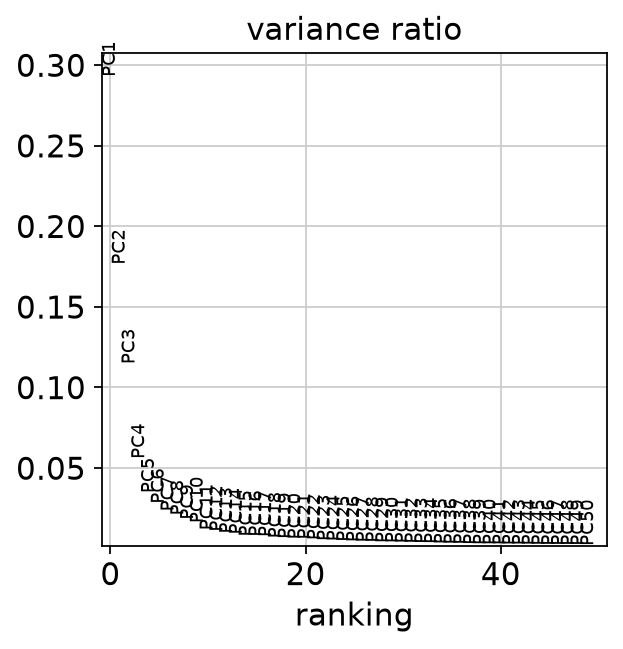

In [9]:
sc.pl.pca_variance_ratio(mdata["prot"], n_pcs=50)

We use 20 PCs because PCs 1-20 capture much of the variance in the data and PCs 20-50 capture little variance of the data and can thus be discarded. 
We now compute a neighborhood graph and a UMAP embedding to visualize the study's variables.

In [10]:
sc.pp.neighbors(mdata["prot"], n_pcs=20, random_state=0)

In [11]:
sc.tl.umap(mdata["prot"], random_state=0)

Now we have our data compressed into 2 dimensions, which we can use to visualize the data.
Let's first visualize and evaluate if there are batch effects, that is, if different donors and different batches form separate clusters.

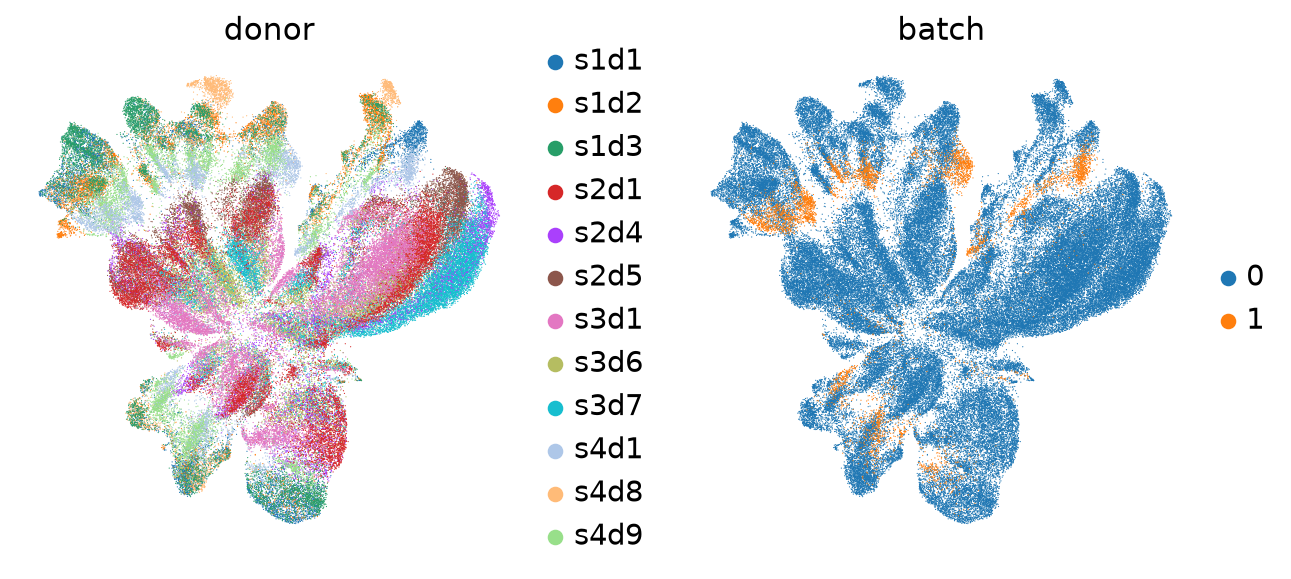

In [12]:
sc.pl.umap(mdata["prot"], color=["donor", "batch"])

We indeed see that some donors form separate clusters. 
Also batches form separate clusters. 
Thus, it seems that batch correction is necessary. 
To confirm, we plot markers of CD4 and CD8 T cells:

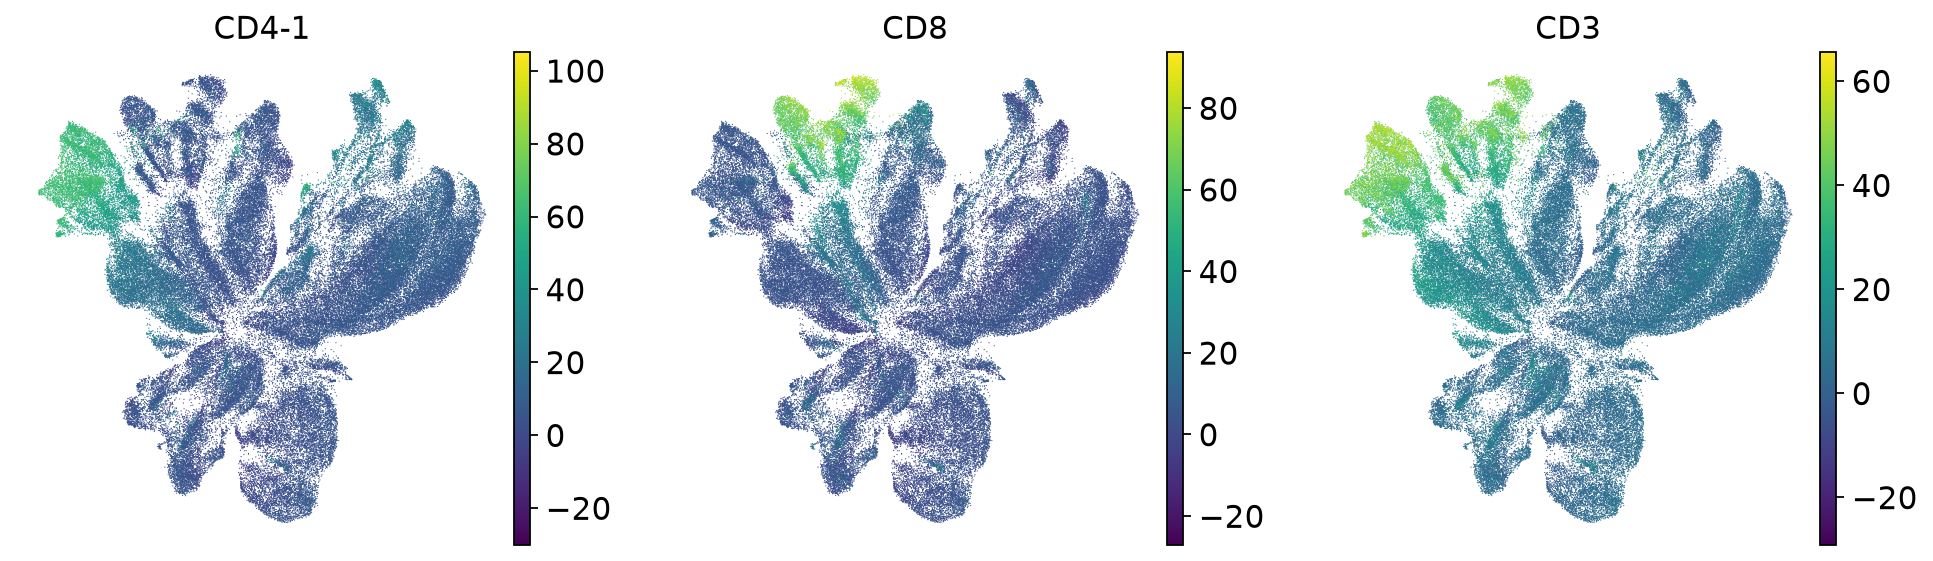

In [13]:
sc.pl.umap(mdata["prot"], color=["CD4-1", "CD8", "CD3"])

CD4 T cells fragment into donor-specific mini-clusters, meaning cells are grouping by donor identity rather than cell type. 
Ideally, CD4 T cells from all donors should cluster together regardless of their donor of origin. 
This donor-driven separation is a batch effect, and must be corrected before downstream analysis.

In [14]:
af_dimensionality_reduction = ln.Artifact.from_mudata(
    mdata,
    key="surface-protein/cite_dimensionality_reduction.h5mu",
    description="CITE-seq data after dimensionality reduction",
)
af_dimensionality_reduction.save()

→ creating new artifact version for key 'surface-protein/cite_dimensionality_reduction.h5mu' in storage 's3://lamin-eu-central-1/VPwcjx3CDAa2'
... uploading 9DWigMKiH7zGL1jy0005.h5mu:  0.0%

... uploading 9DWigMKiH7zGL1jy0005.h5mu: 100.0%
• replacing the existing cache path /var/cache/user/marchena/.cache/lamindb/lamin-eu-central-1/VPwcjx3CDAa2/surface-protein/cite_dimensionality_reduction.h5mu


Artifact(uid='9DWigMKiH7zGL1jy0005', key='surface-protein/cite_dimensionality_reduction.h5mu', description='CITE-seq data after dimensionality reduction', suffix='.h5mu', kind='dataset', otype='MuData', size=1406205468, hash='xlfiRsibE4hRwwkE6fVkTq', n_files=None, n_observations=105907, branch_id=1, created_on_id=1, space_id=1, storage_id=1, run_id=113, schema_id=None, created_by_id=7, created_at=2026-07-29 11:10:27 UTC, is_locked=False, version_tag=None, is_latest=True)

In [15]:
ln.finish()

• please hit CTRL + s to save the notebook in your editor .... still waiting .....
.................. ✓
! returning transform  with same hash & key: Transform(uid='liGMVGre4G5H0007', key='dimensionality_reduction.ipynb', description='Dimensionality Reduction', kind='notebook', hash='9AXoWZ-LnjdIoeh_N7xjtQ', reference=None, reference_type=None, environment=None, plan=None, branch_id=1, created_on_id=1, space_id=1, created_by_id=7, created_at=2026-07-29 10:31:37 UTC, is_locked=False, version_tag=None, is_latest=False)
• new latest Transform version is: liGMVGre4G5H0007
→ finished Run('aPuKLGSFDouWhxAx') after 2m at 2026-07-29 11:11:09 UTC
→ go to: https://lamin.ai/theislab/sc-best-practices/transform/liGMVGre4G5H0007
→ to update your notebook from the CLI, run: lamin save /groups/nils/members/javier/single-cell-best-practices/jupyter-book/surface_protein/dimensionality_reduction.ipynb


## Contributors

We gratefully acknowledge the contributions of:

### Authors

* Javier Marchena-Hurtado
* Daniel Strobl
* Ciro Ramírez-Suástegui

### Reviewers

* Lukas Heumos
* Anna Schaar